In [1]:
import pandas as pd

In [2]:
offers = pd.read_csv("data_offers.csv")
orders = pd.read_csv("data_orders.csv")

In [3]:
offers.shape

(334363, 2)

In [4]:
offers.head()

,order_gk,offer_id
0,3000579625629,300050936206
1,3000627306450,300052064651
2,3000632920686,300052408812
3,3000632771725,300052393030
4,3000583467642,300051001196


In [5]:
offers.dtypes

order_gk    int64
offer_id    int64
dtype: object

In [6]:
offers.isna()

,order_gk,offer_id
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
334358,False,False
334359,False,False
334360,False,False
334361,False,False


In [7]:
offers.sum()

order_gk    1003290154014257596
offer_id     100326132959958611
dtype: int64

In [8]:
orders.shape

(10716, 8)

In [9]:
orders.head()

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds
0,18:08:07,-0.978916,51.456173,60.0,3000583041974,4,1,198.0
1,20:57:32,-0.950385,51.456843,NaN,3000583116437,4,0,128.0
2,12:07:50,-0.969520,51.455544,477.0,3000582891479,4,1,46.0
3,13:50:20,-1.054671,51.460544,658.0,3000582941169,4,1,62.0
4,21:24:45,-0.967605,51.458236,NaN,3000583140877,9,0,NaN


In [10]:
orders.dtypes

order_datetime                    object
origin_longitude                 float64
origin_latitude                  float64
m_order_eta                      float64
order_gk                           int64
order_status_key                   int64
is_driver_assigned_key             int64
cancellations_time_in_seconds    float64
dtype: object

In [11]:
orders.isna()

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds
0,False,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...
10711,False,False,False,True,False,False,False,False
10712,False,False,False,True,False,False,False,False
10713,False,False,False,False,False,False,False,False
10714,False,False,False,True,False,False,False,False


In [12]:
orders.sum()

order_datetime                   18:08:0720:57:3212:07:5013:50:2021:24:4521:21:...
origin_longitude                                                     -10333.687747
origin_latitude                                                      551343.999454
m_order_eta                                                              1242143.0
order_gk                                                         32154410484436371
order_status_key                                                             59909
is_driver_assigned_key                                                        2814
cancellations_time_in_seconds                                            1153717.0
dtype: object

In [13]:
orders['order_datetime'] = pd.to_datetime(orders['order_datetime'])

C:\Users\User\AppData\Local\Temp\ipykernel_4860\2460810386.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orders['order_datetime'] = pd.to_datetime(orders['order_datetime'])


In [14]:
orders.dtypes

order_datetime                   datetime64[ns]
origin_longitude                        float64
origin_latitude                         float64
m_order_eta                             float64
order_gk                                  int64
order_status_key                          int64
is_driver_assigned_key                    int64
cancellations_time_in_seconds           float64
dtype: object

In [15]:
orders['hour'] = orders['order_datetime'].dt.hour

In [16]:
orders.head()

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds,hour
0,2026-07-16 18:08:07,-0.978916,51.456173,60.0,3000583041974,4,1,198.0,18
1,2026-07-16 20:57:32,-0.950385,51.456843,NaN,3000583116437,4,0,128.0,20
2,2026-07-16 12:07:50,-0.969520,51.455544,477.0,3000582891479,4,1,46.0,12
3,2026-07-16 13:50:20,-1.054671,51.460544,658.0,3000582941169,4,1,62.0,13
4,2026-07-16 21:24:45,-0.967605,51.458236,NaN,3000583140877,9,0,NaN,21


In [17]:
pd.crosstab(orders['order_status_key'],orders['is_driver_assigned_key'])

is_driver_assigned_key,0,1
order_status_key,,
4,4496,2811
9,3406,3


In [18]:
def get_failure_category(row):
    if row['order_status_key'] == 4 and row['is_driver_assigned_key'] == 0:
        return 'Cancelled before assignment'
    elif row['order_status_key'] == 4 and row['is_driver_assigned_key'] == 1:
        return 'Cancelled after assignment'
    else:
        return 'Rejected by system'

orders['failure_category'] = orders.apply(get_failure_category, axis=1)

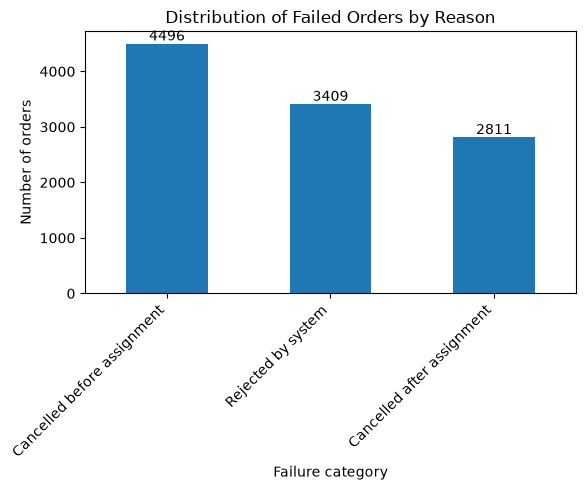

In [19]:
import matplotlib.pyplot as plt

counts =orders['failure_category'].value_counts()

ax = counts.plot(kind='bar', figsize=(6,5))
ax.set_title('Distribution of Failed Orders by Reason')
ax.set_ylabel('Number of orders')
ax.set_xlabel('Failure category')
plt.xticks(rotation=45, ha='right')
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

In [20]:
hourly_counts =orders.groupby(['hour', 'failure_category']).size().unstack(fill_value=0)

In [21]:
hourly_counts

failure_category,Cancelled after assignment,Cancelled before assignment,Rejected by system
hour,,,
0,120,298,265
1,88,219,164
2,78,237,240
3,64,224,225
4,41,50,61
5,25,15,27
6,47,67,45
7,156,164,127
8,314,413,355


In [22]:
hourly_pct = hourly_counts.div(hourly_counts.sum(axis=1), axis=0) * 100

In [23]:
hourly_pct

failure_category,Cancelled after assignment,Cancelled before assignment,Rejected by system
hour,,,
0,17.569546,43.631040,38.799414
1,18.683652,46.496815,34.819533
2,14.054054,42.702703,43.243243
3,12.475634,43.664717,43.859649
4,26.973684,32.894737,40.131579
5,37.313433,22.388060,40.298507
6,29.559748,42.138365,28.301887
7,34.899329,36.689038,28.411633
8,29.020333,38.170055,32.809612


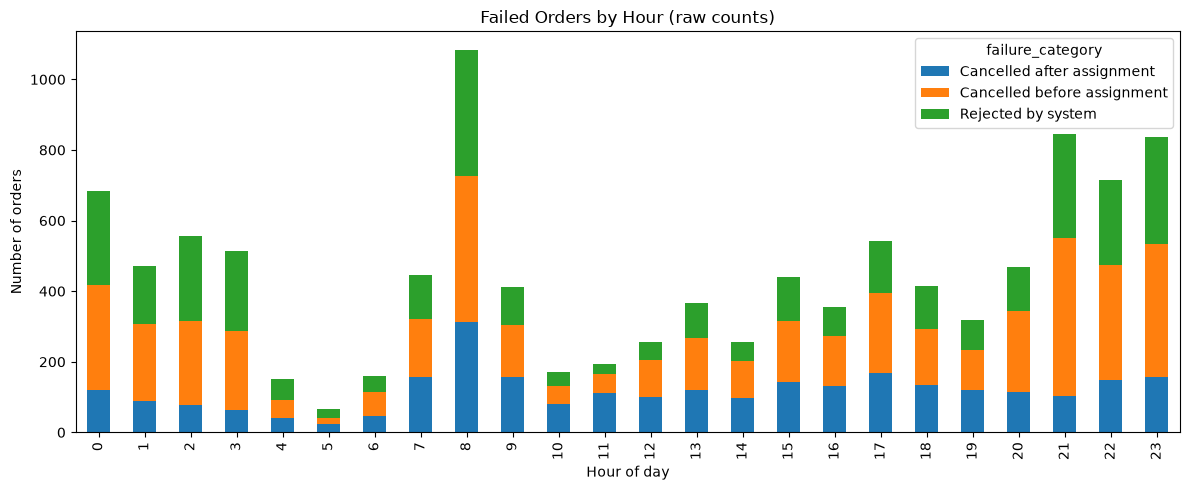

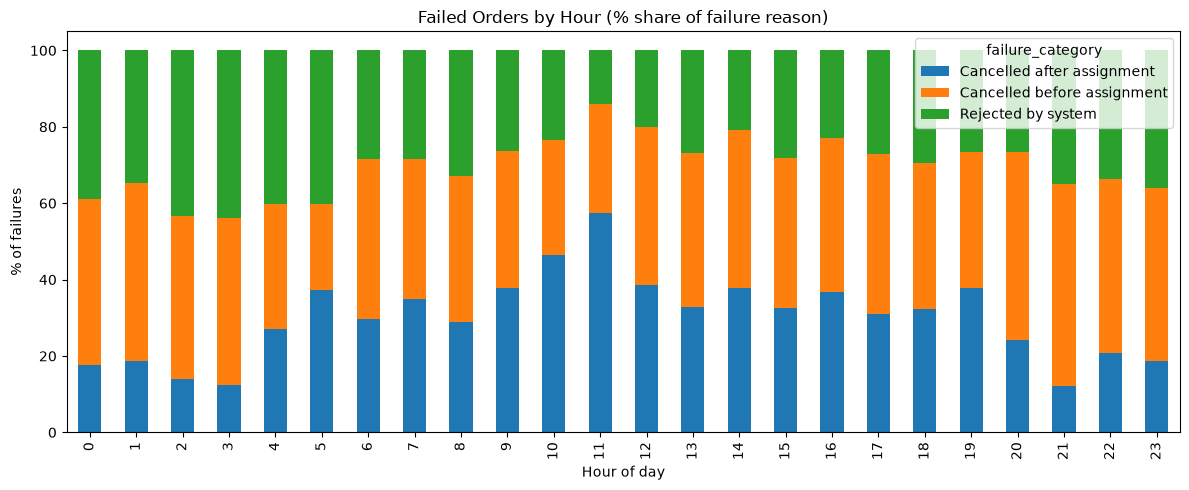

In [24]:
ax1 = hourly_counts.plot(kind='bar', stacked=True, figsize=(12,5))
ax1.set_title('Failed Orders by Hour (raw counts)')
ax1.set_ylabel('Number of orders')
ax1.set_xlabel('Hour of day')
plt.tight_layout()
plt.show()

ax2 = hourly_pct.plot(kind='bar', stacked=True, figsize=(12,5))
ax2.set_title('Failed Orders by Hour (% share of failure reason)')
ax2.set_ylabel('% of failures')
ax2.set_xlabel('Hour of day')
plt.tight_layout()
plt.show()

In [25]:
cancelled = orders[orders['order_status_key'] == 4]

no_driver = cancelled[cancelled['is_driver_assigned_key'] == 0]
with_driver = cancelled[cancelled['is_driver_assigned_key'] == 1]

In [26]:
cancelled['cancellations_time_in_seconds'].describe()

count    7307.000000
mean      157.892021
std       213.366963
min         3.000000
25%        45.000000
50%        98.000000
75%       187.500000
max      4303.000000
Name: cancellations_time_in_seconds, dtype: float64

In [27]:
q99 = cancelled['cancellations_time_in_seconds'].quantile(0.99)
print(q99)

cancelled_clean = cancelled[cancelled['cancellations_time_in_seconds'] <= q99]

996.9399999999996


In [28]:
cancelled_clean = cancelled[cancelled['cancellations_time_in_seconds'] <= q99]

avg_by_hour = cancelled_clean.groupby(['hour', 'is_driver_assigned_key'])['cancellations_time_in_seconds'].mean().unstack()
avg_by_hour.columns = ['No driver assigned', 'Driver assigned']
avg_by_hour

,No driver assigned,Driver assigned
hour,,
0,111.557047,251.356522
1,98.132420,207.976471
2,106.438819,269.506667
3,104.361607,241.196721
4,90.000000,243.219512
5,121.800000,168.217391
6,108.984848,170.466667
7,112.628049,183.548387
8,120.702179,168.915584


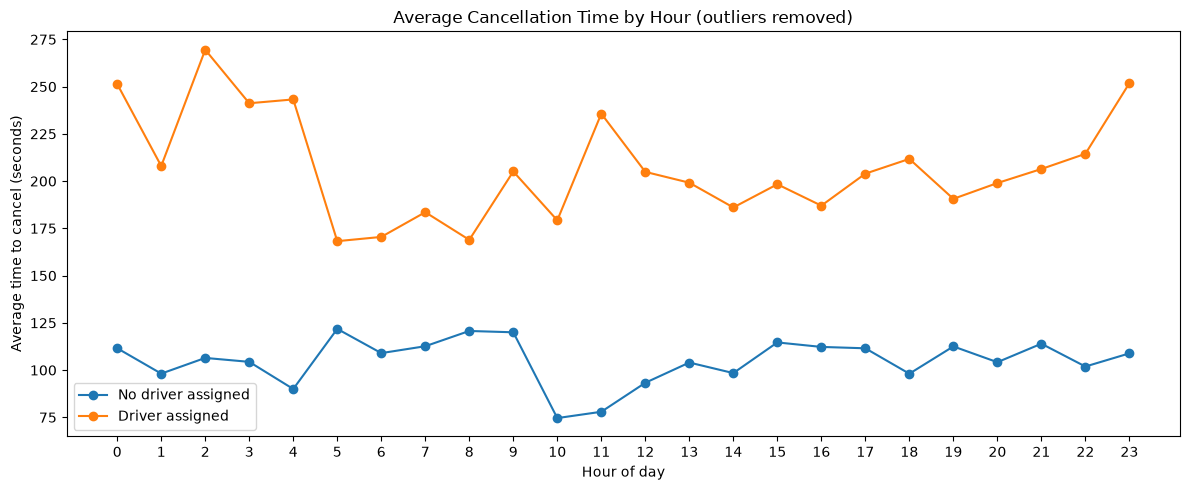

In [29]:
ax = avg_by_hour.plot(kind='line', marker='o', figsize=(12,5))
ax.set_title('Average Cancellation Time by Hour (outliers removed)')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Average time to cancel (seconds)')
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

In [30]:
orders['m_order_eta'].describe()

count    2814.000000
mean      441.415423
std       288.006379
min        60.000000
25%       233.000000
50%       368.500000
75%       653.000000
max      1559.000000
Name: m_order_eta, dtype: float64

In [31]:
orders['m_order_eta'].isna().sum()

np.int64(7902)

In [32]:
c=orders.groupby('is_driver_assigned_key')['m_order_eta'].apply(lambda x: x.notna().sum())
c

is_driver_assigned_key
0       0
1    2814
Name: m_order_eta, dtype: int64

<Axes: >

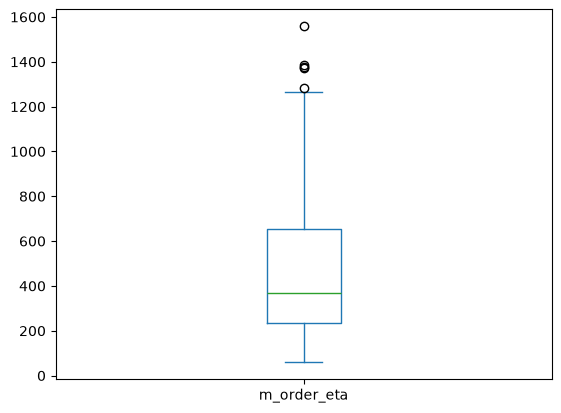

In [33]:
orders['m_order_eta'].plot(kind='box')

In [34]:
eta_data = orders[orders['is_driver_assigned_key'] == 1]
q99_eta = eta_data['m_order_eta'].quantile(0.99)
eta_clean = eta_data[eta_data['m_order_eta'] <= q99_eta]

In [35]:
avg_eta_by_hour = eta_clean.groupby('hour')['m_order_eta'].mean()
avg_eta_by_hour

hour
0     343.116667
1     324.750000
2     391.012821
3     374.904762
4     299.658537
5     411.120000
6     410.521739
7     574.863636
8     622.964169
9     496.253247
10    355.556962
11    390.954955
12    440.787879
13    421.714286
14    387.835052
15    454.790210
16    434.786260
17    509.327273
18    413.421053
19    354.177966
20    300.096491
21    325.277228
22    360.319728
23    393.045752
Name: m_order_eta, dtype: float64

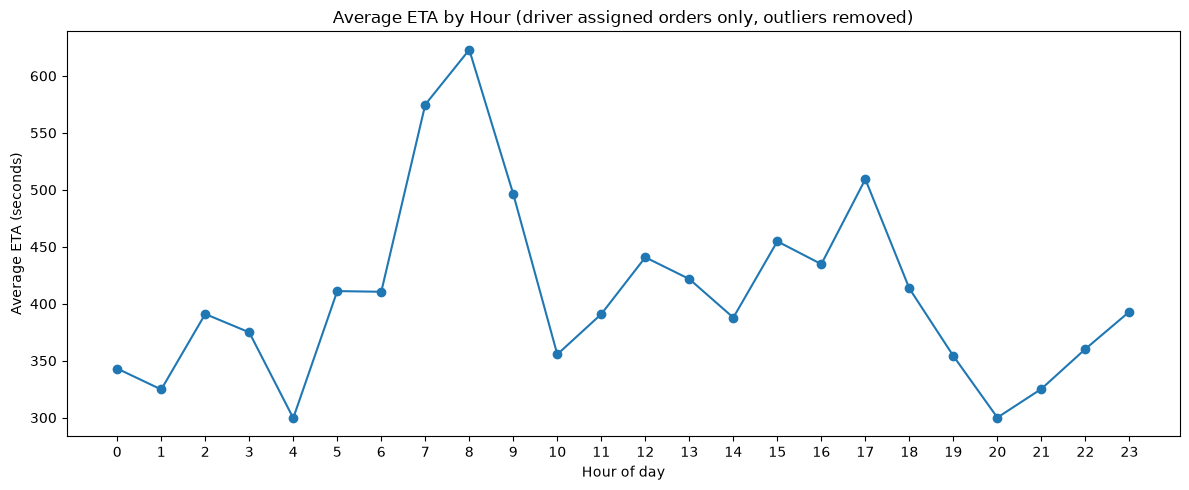

In [36]:
ax = avg_eta_by_hour.plot(kind='line', marker='o', figsize=(12,5))
ax.set_title('Average ETA by Hour (driver assigned orders only, outliers removed)')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Average ETA (seconds)')
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

In [37]:
import h3
import folium

In [38]:
orders['hex_id'] = orders.apply(
    lambda row: h3.latlng_to_cell(row['origin_latitude'], row['origin_longitude'], 8),
    axis=1
)

In [39]:
hex_counts = orders['hex_id'].value_counts()

In [40]:
cumulative_pct = hex_counts.cumsum() / hex_counts.sum()
n_hexes_80pct = (cumulative_pct <= 0.80).sum() + 1

In [41]:
h3.__version__

'4.5.0'

In [42]:
orders['hex_id'].nunique()

144

In [43]:
n_hexes_80pct

np.int64(24)

In [44]:
top_hexes = hex_counts.head(n_hexes_80pct).index.tolist()

fail_counts_per_hex = orders.groupby('hex_id').size()

top_hex_fails = fail_counts_per_hex.loc[top_hexes]
top_hex_fails

hex_id
88195d2b1dfffff    1497
88195d2b1bfffff     870
88195d2b15fffff     774
88195d2b11fffff     707
88195d2b19fffff     667
88195d284dfffff     653
88195d2a27fffff     414
88195d2b0bfffff     372
88195d2a25fffff     362
88195d2b13fffff     346
88195d2b03fffff     257
88195d2b17fffff     210
88195d2b39fffff     184
88195d2861fffff     182
88195d2a21fffff     156
88195d2b3dfffff     153
88195d2b31fffff     143
88195d2869fffff     125
88195d2b3bfffff     115
88195d2b51fffff      98
88195d2b57fffff      92
88195d2a23fffff      91
88195d2b55fffff      85
88195d2b09fffff      81
dtype: int64

In [45]:
import branca.colormap as cm

# center map on mean coordinates
center_lat = orders['origin_latitude'].mean()
center_lon = orders['origin_longitude'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles='cartodbpositron')

# color scale based on fail counts
colormap = cm.LinearColormap(
    colors=['yellow', 'orange', 'red'],
    vmin=top_hex_fails.min(),
    vmax=top_hex_fails.max()
)
colormap.caption = 'Number of failed orders'
colormap.add_to(m)

for hex_id, count in top_hex_fails.items():
    boundary = h3.cell_to_boundary(hex_id)  # returns list of (lat, lon) tuples
    folium.Polygon(
        locations=boundary,
        color='black',
        weight=1,
        fill=True,
        fill_color=colormap(count),
        fill_opacity=0.7,
        tooltip=f'Hex: {hex_id}<br>Failed orders: {count}'
    ).add_to(m)

m

In [48]:
m.save('failed_orders_map.html')